In [19]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

fred = Fred(api_key="7822da3d42a2376127f56be246e66c7b")

In [12]:
start_date = "2019-01-01"
end_date = "2026-05-07"

In [13]:
data = yf.download(["SPY", "QQQ", "DIA", "IWM"], start=start_date, end=end_date)
closes = data["Close"]

[*********************100%***********************]  4 of 4 completed


In [4]:
ratio = closes["TIP"] / closes["IEF"]

<Axes: title={'center': 'TIP / IEF'}, xlabel='Date'>

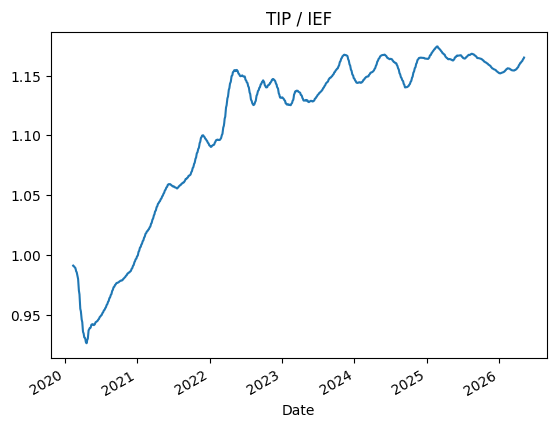

In [6]:
ratio.rolling(30).mean().plot(title="TIP / IEF")

<Axes: xlabel='Date'>

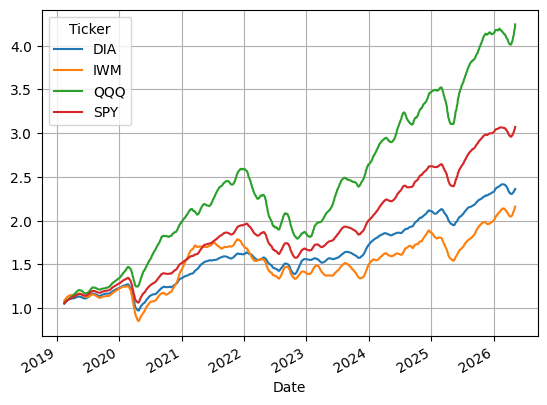

In [17]:
ret_df = closes.pct_change()
(1 + ret_df).cumprod().rolling(30).mean().plot(grid=True)

In [88]:
df = fred.get_series_all_releases("NFCI", realtime_start="2026-01-01")
df = df.loc[df["date"] > pd.Timestamp("2020-01-01")]
df = df.loc[df.groupby("date")["realtime_start"].idxmax()]
df.index = df["date"]

/Users/jplatta/repos/trade_lab/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:7697: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


<Axes: xlabel='date'>

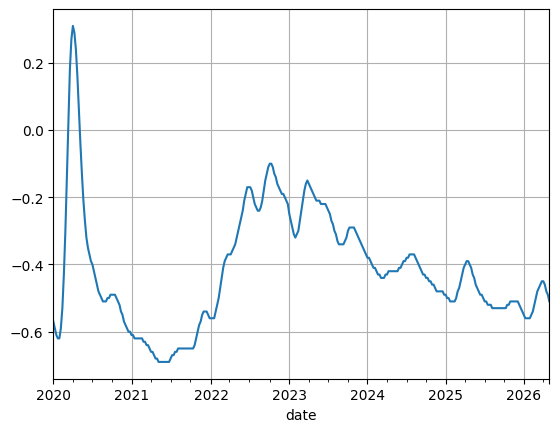

In [90]:
df["value"].plot(grid=True)

In [70]:
df = df[df.index > "2020-01-01"]

<Axes: >

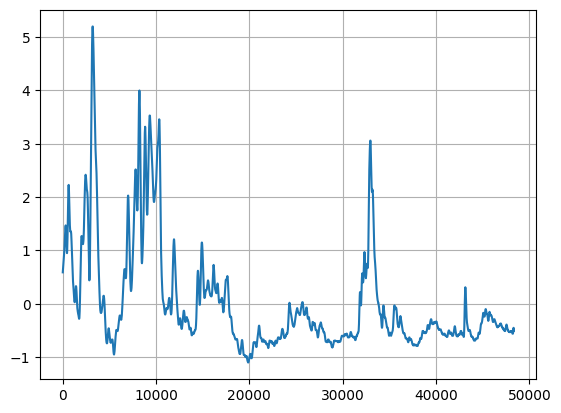

In [85]:
df.loc[df.groupby("date")["realtime_start"].idxmax(), "value"].plot(grid=True)

In [76]:
df.index.min()

Timestamp('2020-01-03 00:00:00')

<Axes: xlabel='date'>

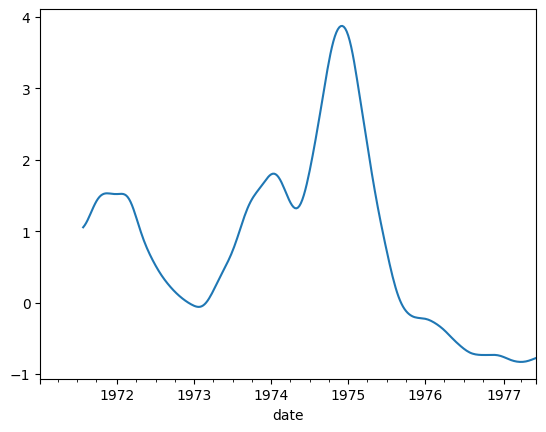

In [55]:
df.groupby(level=0)["value"].mean().rolling(30).mean().plot()

In [ ]:
# df = df['value'].dropna()
# df.plot(grid=True)

In [38]:
results = fred.search("DFII10")

print(results.head(20))

ValueError: Internal Server Error